# Advanced Session: Screening Experimental Solid Electrolytes
AI for Materials Science — Hands-on session 1

In class, we used calculated energies to build a phase diagram. Here we will read experimental
ionic conductivity data from OBELiX and look for solid electrolyte records that meet our conditions.
You will reuse pandas to work with tables and pymatgen to read chemical formulas.

This notebook is for independent study after you finish the assignment. It is optional and ungraded;
there is nothing to submit. The examples are complete, so you can run them first and then try your
own search conditions.

## Today's plan

### 0 · Setup
Install the libraries, import them, and download the data. You do not need an API key or an account.

### A · Reading experimental conductivity data
Check the columns and separate numerical values from upper limits such as `<1E-10`.

### B · Finding candidate records
Use chemical formulas and conductivity values to select records that meet several conditions.

### C · Comparing and saving results
Plot the conductivity distribution, compare records with the same formula, and save the candidate table.

### D · Trying different conditions
Change the conductivity cutoff or excluded elements and see how the results move, then work
through two short tasks of your own.

---
Run the cells one at a time from the top.
Later cells reuse variables created in earlier ones, so skipping ahead gives you a "name is not
defined" error.
Lines starting with `##` inside the code are comments written for you; Python does not run them.

## 0. Setup

### 0-1. Install the libraries

The first cell installs the libraries used in this notebook. `%pip` installs them in the environment
that runs your current notebook. Run this cell in Colab or Jupyter, then move on to the imports.
If you are asked to restart the runtime or kernel, restart it and continue from **0-2**.

In [ ]:
## Install the libraries used below in the current notebook environment.
%pip install -q pandas numpy matplotlib pymatgen requests

### 0-2. Import the libraries and set the output folder

Installing a library makes it available to Python; importing it lets us use it in this notebook.
We will use pandas for tables, NumPy for calculations, and matplotlib for plots.
`requests` downloads the CSV, and pymatgen's `Composition` reads chemical formulas.

`OUTPUT` is a relative path. The code creates `outputs/obelix` under the current working directory,
so you do not need to enter a Mac or Windows folder path.

In [2]:
## BytesIO lets pandas read downloaded file contents as a file in memory.
from io import BytesIO
from pathlib import Path

## The aliases np, pd, and plt are short names used throughout this notebook.
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pymatgen.core import Composition

## This relative path works without entering a personal computer's folder path.
OUTPUT = Path("outputs/obelix")
OUTPUT.mkdir(parents=True, exist_ok=True)

## Limit the displayed rows and text length to keep tables readable.
pd.set_option("display.max_rows", 12)
pd.set_option("display.max_colwidth", 55)
## Four significant figures keep very small conductivities from appearing as 0.0.
pd.set_option("display.float_format", lambda value: f"{value:.4g}")

### 0-3. Download the data

OBELiX collects experimental room-temperature ionic conductivity measurements for solid electrolytes.
The copy used here contains **599 records**.

The cell below downloads the CSV file over HTTP. We then apply our search conditions to the table
with pandas. With the MP API, we sent search conditions to a server; here, we download the table first
and filter it in the notebook.

`DATA_REVISION` identifies the saved version of the data so that rerunning this notebook gives you
the same starting table. It is not a library version or an API key.

In [3]:
## Use the same saved dataset each time; no separate data folder is needed to start.
DATA_REVISION = "4eaac889809dd489e3bae468c45d5c0e02b9147a"
DATA_URL = (
    "https://raw.githubusercontent.com/NRC-Mila/OBELiX/"
    f"{DATA_REVISION}/data/downloads/all.csv"
)

## Download the file; raise_for_status reports an unsuccessful HTTP response.
response = requests.get(DATA_URL, timeout=30)
response.raise_for_status()

## IDs are labels, so read them as strings even when they look like numbers.
raw = pd.read_csv(BytesIO(response.content), dtype={"ID": "string"})

## Save the original file so that you can inspect it again later.
(OUTPUT / "obelix_original.csv").write_bytes(response.content)
print(f"{len(raw)} records, {len(raw.columns)} columns")
display(raw[["ID", "Reduced Composition", "Ionic conductivity (S cm-1)", "Family"]].head())

599 records, 28 columns


,ID,Reduced Composition,Ionic conductivity (S cm-1),Family
0,jqc,Li7BiO6,1.58489e-06,hexaoxometalates
1,oi6,Li7SbO6,6.7e-08,hexaoxometalates
2,2t8,LiV(PO4)F,8.1e-07,Tavorite
3,ro9,Li3BP2O8,9.6e-12,Borophosphates
4,7cr,Li2NaBP2O8,4.4e-18,Borophosphates


## A. Reading experimental conductivity data

### A-1. Check the columns

Before filtering a table, check what each column means and which values are missing.
We will use shorter column names in the code while keeping `raw` unchanged.

| Original column | What it contains |
|---|---|
| `ID` | An identifier for one literature record |
| `Reduced Composition` | The formula we will show in tables |
| `True Composition` | The full unit-cell composition, used below to identify the elements |
| `Ionic conductivity (S cm-1)` | The representative ionic conductivity, in S/cm |
| `IC (Total)`, `IC (Bulk)` | Separately recorded total and bulk conductivities; some values are missing |
| `Family` | The material or structure family label used in the dataset |
| `DOI` | The DOI of a linked publication; a cell may contain several DOIs |

When both total and bulk conductivity are reported, the representative column uses **total**
conductivity. Do not read that entire column as bulk conductivity.
Room-temperature data also does not mean that every measurement used exactly the same temperature
or experimental conditions.

In [4]:
## Rename only the columns we will use. copy() leaves raw unchanged.
df = raw.rename(columns={
    "ID": "record_id",
    "Reduced Composition": "formula",
    "True Composition": "cell_formula",
    "Ionic conductivity (S cm-1)": "sigma_reported",
    "IC (Total)": "sigma_total_S_cm",
    "IC (Bulk)": "sigma_bulk_S_cm",
    "Family": "family",
    "Space group #": "spacegroup_number",
    "DOI": "doi",
}).copy()

## Strip surrounding spaces; keep IDs and DOIs to distinguish records sharing a formula.
df["formula"] = df["formula"].str.strip()
df["doi"] = df["doi"].str.strip()
df["data_origin"] = "experimental; OBELiX"

## Compare column types and missing-value counts. Look closely at sigma_reported.
columns = ["record_id", "formula", "sigma_reported", "sigma_total_S_cm",
           "sigma_bulk_S_cm", "family", "doi"]
display(pd.DataFrame({
    "dtype": df[columns].dtypes.astype(str),
    "missing": df[columns].isna().sum(),
}))

,dtype,missing
record_id,string,0
formula,str,0
sigma_reported,str,0
sigma_total_S_cm,float64,570
sigma_bulk_S_cm,float64,571
family,str,33
doi,str,0


### A-2. Separate numerical values from upper limits

The conductivity column contains values such as `0.001` as well as **upper limits** such as `<1E-10`.
The latter means "less than 10⁻¹⁰ S/cm." It does not mean the value is exactly 10⁻¹⁰ S/cm or zero.

Keep the original text and make two numerical columns:

- `sigma_S_cm`: values reported without an inequality sign
- `sigma_upper_S_cm`: the upper bound following `<`

Later, the variable `exact_records` refers to records reported as numbers rather than upper limits.
It does not imply that those measurements have no uncertainty.

In [5]:
## Remove surrounding spaces and flag records that start with <.
df["sigma_reported"] = df["sigma_reported"].astype("string").str.strip()
df["is_upper_limit"] = df["sigma_reported"].str.startswith("<", na=False)

## Read the number after removing <. Unreadable text becomes NaN.
numeric_part = pd.to_numeric(
    df["sigma_reported"].str.removeprefix("<").str.strip(), errors="coerce"
)

## where keeps values only where the condition is True; other entries become NaN.
## ~ reverses True and False, selecting records that are not upper limits.
df["sigma_S_cm"] = numeric_part.where(~df["is_upper_limit"])
df["sigma_upper_S_cm"] = numeric_part.where(df["is_upper_limit"])

## Every entry in this dataset should contain a positive number or positive upper bound.
unreadable = numeric_part.isna() | numeric_part.le(0)
if unreadable.any():
    display(df.loc[unreadable, ["record_id", "sigma_reported"]])
    raise ValueError("Check the conductivity text in the records shown above.")

print("Numeric-valued records:", int(df["sigma_S_cm"].notna().sum()))
print("Upper-limit records   :", int(df["is_upper_limit"].sum()))
display(df.loc[df["is_upper_limit"],
               ["record_id", "formula", "sigma_reported", "sigma_S_cm", "sigma_upper_S_cm"]].head())

Numeric-valued records: 562
Upper-limit records   : 37


,record_id,formula,sigma_reported,sigma_S_cm,sigma_upper_S_cm
5,47i,Li4P2O7,<1E-10,<NA>,1e-10
45,ecp,LaLiO2,<1E-10,<NA>,1e-10
49,1xt,LiSbO2,<1E-10,<NA>,1e-10
50,kbo,Li2Sr2Al(PO4)3,<1E-10,<NA>,1e-10
58,4kt,Li2CrCl4,<1E-10,<NA>,1e-10


You should see **562 records reported as numbers and 37 upper-limit records**.
We will use the 562 numerical values in the histogram and state how many records were left out.

For a cutoff of 10⁻³ S/cm, a record reported as `<1E-10` cannot pass.
If we lower the cutoff to 10⁻¹² S/cm, however, we cannot tell whether that record passes.
Our search function will keep this second case in a separate **uncertain** table.

## B. Finding candidate records

### B-1. Read the elements in each formula

We will look for records containing **S**. Searching a formula for the character `S` would also match
Si, Sb, and Sr. Use pymatgen's `Composition` to distinguish the element symbols.

One formula in `Reduced Composition` uses `*` to join a hydrate expression that `Composition` cannot
read directly. We will use the parseable **`True Composition`** column to identify the elements.
The atom counts may differ between the two columns, but the unit-cell composition still tells us
which elements are present. Tables will continue to show the original reduced formula.

In [6]:
## Composition reads a chemical formula as elements and atom counts.
def elements_in_formula(formula):
    composition = Composition(formula)
    ## A set collects the element symbols without duplicates.
    return {element.symbol for element in composition.elements}

## map applies the function to each row without changing the original formula text.
df["elements"] = df["cell_formula"].map(elements_in_formula)

## Check that S and Si are recognized as different elements.
display(pd.DataFrame({
    "formula": ["Li7P3S11", "Li4SiO4"],
    "elements": [elements_in_formula("Li7P3S11"), elements_in_formula("Li4SiO4")],
}))

,formula,elements
0,Li7P3S11,"{Li, S, P}"
1,Li4SiO4,"{Li, Si, O}"


### B-2. Write a search function

Our starting conditions are: **contains S, contains neither O nor Ge, and has a conductivity of at
least 10⁻³ S/cm**. These are conditions for this exercise, not a general acceptance standard for
battery electrolytes.

The function takes a table, a minimum conductivity, a set of required elements, and a set of excluded
elements. It returns two tables: **confirmed candidates** and **records whose upper limits leave the
result uncertain**.

For Python sets, `required_elements <= elements` checks that all required elements are present.
The `&` operator finds elements shared by two sets. An empty intersection means none of the excluded
elements are present.

In [7]:
## Put the search in a function so that we can reuse it with different conditions.
def find_candidates(table, min_sigma, required_elements, excluded_elements):
    if not np.isfinite(min_sigma) or min_sigma <= 0:
        raise ValueError("Enter a finite conductivity cutoff greater than zero.")

    ## <= checks that all required elements are present; & finds excluded elements.
    ## lambda defines a short function that checks the element set in each row.
    element_mask = table["elements"].map(
        lambda elements: required_elements <= elements
        and not (excluded_elements & elements)
    )
    matching_elements = table.loc[element_mask].copy()

    ## Numerical values let us confirm whether the conductivity meets the cutoff.
    passing = matching_elements.loc[matching_elements["sigma_S_cm"] >= min_sigma]

    ## For a reported <U, U above the cutoff leaves the result uncertain.
    ## If U is at or below the cutoff, the record certainly fails and is left out here.
    uncertain = matching_elements.loc[matching_elements["sigma_upper_S_cm"] > min_sigma]

    ## Sort confirmed values from highest to lowest; keep upper limits separate.
    return passing.sort_values("sigma_S_cm", ascending=False), uncertain

### B-3. Run the search

Set the conductivity cutoff and the two element sets below, then call the function from B-2.
Start with these values so that you can compare your output with the example.
We will change them in section D.

In [8]:
## Start with these settings. Change these three lines when you try your own search.
MIN_SIGMA = 1e-3                  ## In S/cm: 1e-3 S/cm = 1 mS/cm.
REQUIRED_ELEMENTS = {"S"}
EXCLUDED_ELEMENTS = {"O", "Ge"}

## Unpack the two returned tables into separate variables.
candidates, uncertain = find_candidates(
    df, MIN_SIGMA, REQUIRED_ELEMENTS, EXCLUDED_ELEMENTS
)

## nunique counts distinct values; here it counts different formula strings.
print("Confirmed candidates       :", len(candidates))
print("Distinct formula strings   :", candidates["formula"].nunique())
print("Uncertain upper-limit rows :", len(uncertain))

result_columns = ["record_id", "formula", "sigma_S_cm", "family", "doi"]
display(candidates[result_columns].head(10))
if not uncertain.empty:
    display(uncertain[["record_id", "formula", "sigma_reported", "doi"]].head())

Confirmed candidates       : 47
Distinct formula strings   : 42
Uncertain upper-limit rows : 0


,record_id,formula,sigma_S_cm,family,doi
209,ete,Li9.54Si1.74P1.44S11.7Cl0.3,0.025,LGPS,10.1038/nenergy.2016.30
200,ui6,Li10.35(Sn0.27Si1.08)P1.65S12,0.011,LGPS,10.1021/acs.chemmater.7b00886
198,8ub,Li10.5(Sn0.2Si0.8)1.5P1.5S12,0.00879,LGPS,10.1021/acs.chemmater.7b00886
9,ptg,Li7P3S11,0.0086,NaN,10.1021/acs.chemmater.6b02163
199,7tu,Li10.2(Sn0.2Si0.8)1.2P1.8S12,0.00782,LGPS,10.1021/acs.chemmater.7b00886
191,9lx,Li10SnP2S12,0.007,LGPS,10.1021/ja407393y
180,mqo,Li3.45Si0.45P0.55S4,0.00673,LGPS,10.1039/c4fd00143e
210,k4x,Li10.35Si1.35P1.65S12,0.0065,LGPS,10.1107/s2052520615022283
182,8nc,Li3.425Si0.425P0.575S4,0.00565,LGPS,10.1039/c4fd00143e
196,nip,Li9.81Sn0.81P2.19S12,0.0055,LGPS,10.1107/s2052520615022283


With the starting conditions, you should get **47 records, 42 distinct formula strings, and no
uncertain records**. The counts differ because more than one record can have the same formula.
The 42 formula strings do not mean 42 distinct crystal structures.

Pick a record near the top and look at its `family` and `doi` fields.
The original `Family` labels use inconsistent capitalization and singular/plural forms. We keep them
as recorded here; they would need cleaning before a comparison by family.

## C. Comparing and saving results

### C-1. Plot the conductivity distribution

Conductivity spans several orders of magnitude. On a linear axis, the small values would be crowded
together, so we will plot **log₁₀(σ / [S/cm])** instead.
An x-axis value of −3 represents 10⁻³ S/cm; −6 represents 10⁻⁶ S/cm.

The plot shows all numerically reported conductivities and the candidates selected in B-3.
Upper-limit records are left out because we do not know where to place them on this axis.
The histogram therefore covers 562 numerical records, not all 599 records.

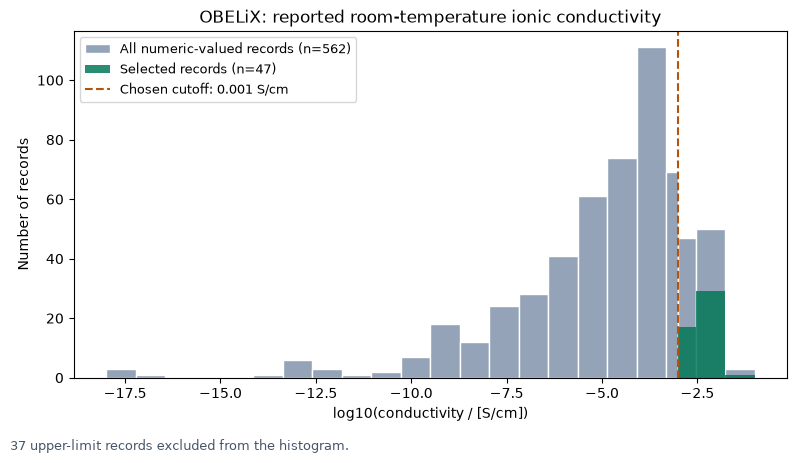

In [9]:
## Take the logarithm of positive numerical values; keep the original df intact.
exact_records = df.loc[df["sigma_S_cm"].notna()].copy()
log_sigma = np.log10(exact_records["sigma_S_cm"])
bin_edges = np.linspace(np.floor(log_sigma.min()), np.ceil(log_sigma.max()), 23)
## Make the cutoff a bin edge so that selected bars do not extend below it.
bin_edges = np.unique(np.append(bin_edges, np.log10(MIN_SIGMA)))

## fig is the whole figure; ax is the plotting area with its axes.
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(log_sigma, bins=bin_edges, color="#94a3b8", edgecolor="white",
        label=f"All numeric-valued records (n={len(exact_records)})")
ax.hist(np.log10(candidates["sigma_S_cm"]), bins=bin_edges,
        color="#047857", alpha=0.85, label=f"Selected records (n={len(candidates)})")
ax.axvline(np.log10(MIN_SIGMA), color="#b45309", linestyle="--",
           label=f"Chosen cutoff: {MIN_SIGMA:g} S/cm")
ax.set(xlabel="log10(conductivity / [S/cm])", ylabel="Number of records",
       title="OBELiX: reported room-temperature ionic conductivity")
ax.legend(fontsize=9)

## State the excluded record count on the plot before saving the figure.
fig.text(0.01, 0.01, f"{df['is_upper_limit'].sum()} upper-limit records excluded from the histogram.",
         fontsize=9, color="#475569")
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(OUTPUT / "obelix_conductivity_distribution.png", dpi=170)
plt.show()

The green bars are a subset of the gray bars, so do not add their counts together.
Some gray records above the conductivity cutoff are not green because **the element conditions also
apply**. Check `REQUIRED_ELEMENTS` and `EXCLUDED_ELEMENTS` if the selection is different from what
you expected.

### C-2. Compare records with the same formula

Select the records for **Li₇P₃S₁₁**. Would matching formula strings be enough reason to delete one row
as a duplicate? Compare the conductivities, record IDs, and DOI fields before deciding.

In [10]:
## eq tests for an exact string match with the chosen formula.
REPEAT_FORMULA = "Li7P3S11"
same_formula = df.loc[df["formula"].eq(REPEAT_FORMULA)].copy()
same_formula = same_formula.sort_values("sigma_S_cm", ascending=False)

## Compare the representative value, separate total/bulk values, and DOI fields.
display(same_formula[["record_id", "formula", "sigma_reported",
                      "sigma_total_S_cm", "sigma_bulk_S_cm", "doi"]])
print("Records:", len(same_formula))
print("Distinct DOI strings:", same_formula["doi"].nunique())

## A field may join several DOIs with |. Print each one so that it is not truncated.
## itertuples reads one row at a time; split separates text at each | character.
for record in same_formula.itertuples():
    print(f"\n{record.record_id}: linked references")
    for doi in record.doi.split("|"):
        print("  https://doi.org/" + doi.strip())

,record_id,formula,sigma_reported,sigma_total_S_cm,sigma_bulk_S_cm,doi
9,ptg,Li7P3S11,0.0086,NaN,NaN,10.1021/acs.chemmater.6b02163
7,mdp,Li7P3S11,0.0032,NaN,NaN,10.1039/c3ee41655k|10.1016/j.ssi.2007.05.020|10.101...


Records: 2
Distinct DOI strings: 2

ptg: linked references
  https://doi.org/10.1021/acs.chemmater.6b02163

mdp: linked references
  https://doi.org/10.1039/c3ee41655k
  https://doi.org/10.1016/j.ssi.2007.05.020
  https://doi.org/10.1016/j.ssi.2006.04.017


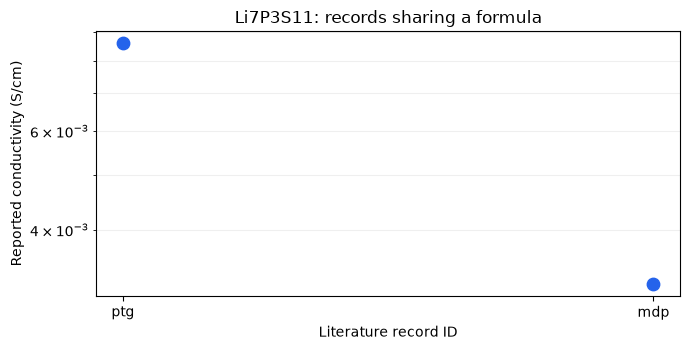

In [11]:
## Plot numerical values by record ID; match each ID to the DOI in the table above.
same_formula_numeric = same_formula.dropna(subset=["sigma_S_cm"])
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(same_formula_numeric["record_id"].astype(str),
           same_formula_numeric["sigma_S_cm"], s=80, color="#2563eb")
## A logarithmic y-axis shows conductivity ratios more clearly.
ax.set_yscale("log")
ax.set(xlabel="Literature record ID", ylabel="Reported conductivity (S/cm)",
       title=f"{REPEAT_FORMULA}: records sharing a formula")
ax.grid(axis="y", which="both", alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT / "obelix_same_formula_records.png", dpi=170)
plt.show()

The two records have different linked references. Some DOI fields contain several DOIs joined by
`|`; the code prints each link separately so that the table does not hide them.
Open the linked publications to check the conductivity and structure information.
Deleting a row just because its formula matches another row would lose that record.
Keeping individual measurements and choosing one representative value per formula are different tasks.

Check the publications before attributing the difference to synthesis conditions, sample state,
measurement temperature, or measurement method. The table alone does not establish the cause.
High ionic conductivity is also only one part of evaluating a battery electrolyte: electronic
conductivity, reactions with the electrodes, and processing requirements matter too.

<details>
<summary>Check your interpretation</summary>
<p>The Li₇P₃S₁₁ records report 0.0032 and 0.0086 S/cm. Both pass our starting conductivity cutoff.
The table shows that the values differ, but explaining why requires reading the publications linked
to each record.</p>
</details>

### C-3. Save the candidate table

Save the candidates as a CSV file, keeping the reported values, units, record IDs, and DOIs.
The uncertain records go into a separate file so that you can review them later.
In Colab, open the file panel on the left and download the files from `outputs/obelix`.
In Jupyter, this folder is created under the notebook's working directory.

In [12]:
## Export readable formulas and record details instead of the Python sets in elements.
export_columns = ["record_id", "formula", "sigma_reported", "sigma_S_cm",
                  "sigma_upper_S_cm", "sigma_total_S_cm", "sigma_bulk_S_cm",
                  "family", "spacegroup_number", "doi", "data_origin"]

## Save the search settings and data revision alongside the results.
for label, table in [("candidates", candidates), ("uncertain", uncertain)]:
    exported = table[export_columns].copy()
    exported["cutoff_S_cm"] = MIN_SIGMA
    exported["required_elements"] = ",".join(sorted(REQUIRED_ELEMENTS))
    exported["excluded_elements"] = ",".join(sorted(EXCLUDED_ELEMENTS))
    exported["source_revision"] = DATA_REVISION
    exported.to_csv(OUTPUT / f"obelix_{label}.csv", index=False, encoding="utf-8-sig")

print("Saved folder:", OUTPUT)
print("Candidate rows:", len(candidates), "| Uncertain rows:", len(uncertain))

Saved folder: outputs/obelix
Candidate rows: 47 | Uncertain rows: 0


## D. Trying different conditions

### D-1. Change one condition at a time

Choose one of the following changes and predict the result before running the next cell.
There is nothing to submit.

1. Keep the element conditions and lower the conductivity cutoff to **10⁻⁴ S/cm**.
2. Keep the element conditions and raise the cutoff to **10⁻² S/cm**.
3. Keep the cutoff at 10⁻³ S/cm and **allow Ge**.

The next cell applies each case to the same table and compares the counts. It does not replace the
`candidates` table from B-3.
To update the full candidate table, plots, and saved CSV files, **change the three settings in B-3
and rerun B-3 through C-3**.

In [13]:
## Each tuple contains a label, a conductivity cutoff, and a set of excluded elements.
scenarios = [
    ("Baseline", 1e-3, {"O", "Ge"}),
    ("Lower cutoff", 1e-4, {"O", "Ge"}),
    ("Higher cutoff", 1e-2, {"O", "Ge"}),
    ("Allow Ge", 1e-3, {"O"}),
]

## Run the same function for each case and collect one summary row per case.
scenario_rows = []
for name, cutoff, excluded in scenarios:
    selected, not_decided = find_candidates(df, cutoff, {"S"}, excluded)
    scenario_rows.append({
        "scenario": name,
        "cutoff_S_cm": cutoff,
        "excluded_elements": ", ".join(sorted(excluded)),
        "candidate_records": len(selected),
        "distinct_formula_strings": selected["formula"].nunique(),
        "uncertain_records": len(not_decided),
    })

scenario_summary = pd.DataFrame(scenario_rows)
display(scenario_summary)

,scenario,cutoff_S_cm,excluded_elements,candidate_records,distinct_formula_strings,uncertain_records
0,Baseline,0.001,"Ge, O",47,42,0
1,Lower cutoff,0.0001,"Ge, O",61,54,0
2,Higher cutoff,0.01,"Ge, O",2,2,0
3,Allow Ge,0.001,O,70,61,0


<details>
<summary>Check your results</summary>
<p>The starting conditions give 47 records and 42 formula strings. Lowering the cutoff to
10⁻⁴ S/cm gives 61 records and 54 formulas; raising it to 10⁻² S/cm gives 2 records and 2 formulas.
Allowing Ge gives 70 records and 61 formulas. These counts refer to matching literature records
and formula strings.</p>
<p>Lowering the minimum conductivity should not reduce the candidate count. Removing an exclusion
should not reduce it either. If your results disagree, check the inequality and element conditions.</p>
</details>

### D-2. Try a cutoff below the reported upper limits

Lowering the cutoff far enough makes some upper-limit records uncertain.
The next cell removes the element conditions and uses a cutoff of 10⁻¹² S/cm.
Compare the confirmed and uncertain counts. This is why we kept upper-limit records separately
instead of discarding them with `dropna()`.

In [14]:
## An empty set imposes no required or excluded element conditions.
low_cutoff_candidates, low_cutoff_uncertain = find_candidates(
    df, min_sigma=1e-12, required_elements=set(), excluded_elements=set()
)

print("Confirmed candidates:", len(low_cutoff_candidates))
print("Cannot decide from the upper limit:", len(low_cutoff_uncertain))
display(low_cutoff_uncertain[["record_id", "formula", "sigma_reported"]].head())

Confirmed candidates: 549
Cannot decide from the upper limit: 37


,record_id,formula,sigma_reported
5,47i,Li4P2O7,<1E-10
45,ecp,LaLiO2,<1E-10
49,1xt,LiSbO2,<1E-10
50,kbo,Li2Sr2Al(PO4)3,<1E-10
58,4kt,Li2CrCl4,<1E-10


### D-3. Task 1 — change the chemistry

Everything so far started from sulfides. Do the same search for **oxides**: require `O`, exclude
`S`, and keep the 10⁻³ S/cm cutoff.

Call `find_candidates` yourself in the cell below and print three things.

1. How many confirmed candidates, and how many distinct formula strings.
2. The three highest conductivities, with their `record_id` and `formula`.
3. Whether the oxide list is longer or shorter than the sulfide list from B-3.

Everything you need is already defined: `find_candidates`, `df`, and the `result_columns` list.
Python set literals are written `{"O"}`.

In [ ]:
## Write your code here.
## Hint: oxide_candidates, oxide_uncertain = find_candidates(df, ..., {...}, {...})

### D-4. Task 2 — the same material in more than one paper

In C-2 you compared records for a formula you picked by hand. Now let the table pick it for you.

Working from the `candidates` table produced in B-3:

1. Find the formula string that appears in the **most** records. `value_counts()` on the `formula`
   column sorts them for you, so the first entry of its index is the one you want.
2. Print those records with their `record_id`, `sigma_S_cm` and `doi`.
3. Work out the ratio between the highest and the lowest reported conductivity for that formula.
4. Write one sentence on what you would have to check in those papers before calling the difference
   real.

`table.loc[table["formula"].eq(name)]` selects the rows for one formula, the same way C-2 did.

In [ ]:
## Write your code here.
## Hint: counts = candidates["formula"].value_counts()
##       repeated = counts.index[0]